# St-Patricks-Day -- is there a 'wearin' o' the green' rally?
### A folk calendar bump, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every March you'll hear that the stock market gets a **St. Patrick's Day bump** -- the 'wearin' o' the green' rally, where equities are supposed to do unusually well on (or around) March 17. This notebook runs the only test that matters: across almost a century of S&P 500 history, is the St. Patrick's session actually greener than any other trading day, or is it just one lucky number in a calendar full of them?

> **This is the plain-language layer.** Want the HAC t-stats, the placebo, the multiple-comparisons sweep and the sub-period split? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from st_patricks_day import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'fp': 'df3897aef897', 'year_start': 1928, 'year_end': 2026, 'n_days': 24728, 'n_stpat': 99, 'mean_stpat_bps': 14.8, 'tstat_stpat_hac': 1.13, 'mean_all_bps': 2.4, 'contrast_vs_all_bps': 12.4, 'tstat_welch_all': 0.93, 'pval_welch_all': 0.353, 'mean_march_other_bps': 0.7, 'contrast_vs_march_bps': 14.1, 'tstat_welch_march': 1.04, 'pval_welch_march': 0.299, 'n_placebo': 99, 'mean_placebo_bps': 3.5, 'pval_placebo_march': 0.877, 'pval_bonferroni_17': 1.0, 'sub_a_lbl': '1928-1960', 'sub_a_n': 33, 'sub_a_bps': -9.9, 'sub_a_t': -0.43, 'sub_b_lbl': '1961-1990', 'sub_b_n': 30, 'sub_b_bps': -12.2, 'sub_b_t': -0.89, 'sub_c_lbl': '1991-2026', 'sub_c_n': 36, 'sub_c_bps': 59.9, 'sub_c_t': 3.27, 'net_mean_bps': 12.8, 'net_tstat_hac': 0.98, 'strat_per_event_pct': 0.128, 'mc_31': (67, -24.8, 0.107), 'mc_10': (99, 23.1, 0.265), 'mc_17': (99, 14.8, 0.299), 'mc_03': (99, 8.6, 0.433), 'mc_24': (99, 3.5, 0.877)}


GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the St. Patrick's session greener than average? | **Barely.** Mean **+14.8 bps** vs **+2.4 bps** for all other days -- but HAC t = **1.13**, well below the t=2 bar. |
| Does it beat other March days? | **No, not significantly.** +14.1 bps richer than the rest of March, Welch p = **0.30**. |
| Is it special, or just one lucky day? | A snooper testing five March anchor days finds nothing survives Bonferroni; the placebo (March 24) is a flat +3.5 bps. |
| Where does the 'bump' come from? | **One regime.** It is +60 bps in 1991-2026 but *negative* in 1928-1990. A genuine signal doesn't flip sign across history. |
| Could you trade it? | **No.** One day a year, ~13 bps net of costs, dominated by just holding the index. |

> The St. Patrick's Day bump is folklore: a mildly positive day that owes its whole reputation to a single lucky modern regime and the fact that markets drift up anyway.

## 1 - The claim

> *"The market rallies on St. Patrick's Day -- the 'wearin' o' the green' bump. Buy the S&P on March 17 and you'll catch a reliably green session."*

Unlike most anomalies, this one has **no academic paper** behind it -- there is no peer-reviewed 'St. Patrick's Day effect'. It is pure calendar superstition, in the same family as the Santa Claus rally and the Halloween indicator, but thinner: a single fixed civil-calendar date, March 17.

## 2 - So what?

If a single named holiday reliably delivered an above-average return, it would be the easiest trade in finance: hold the index for one day a year and skip the rest. The interesting question is *why* a perfectly ordinary day acquires a green reputation -- and the answer is a clinic in how calendar folklore is born from a lucky sub-sample and the market's natural upward drift.

## 3 - How would we even know?

Four traps to avoid:

1. **The drift baseline.** Stocks drift up ~+2.4 bps/day unconditionally. Any single day will *look* green on average. The right question is whether March 17 beats that baseline by a statistically real margin -- HAC t >= 2, not just a positive number.
2. **March seasonality.** March may itself be a good (or bad) month. We compare the St. Patrick session against *other March days*, not just against the whole year, to strip out generic spring seasonality.
3. **A placebo.** We test March 24 (one week later) with the same machinery. If a folklore-free day looks just as green, the St. Patrick result is noise.
4. **Multiple comparisons.** March 17 was picked *because* of the holiday. A snooper testing many March anchor days would find the most extreme by chance, so we Bonferroni-correct across a grid.

We test all of this on ^GSPC daily returns from 1928 to 2026 (99 St. Patrick sessions).

## 4 - The teardown -- let's actually look

**First, the headline:** the St. Patrick's session mean vs the unconditional drift and vs the rest of March.

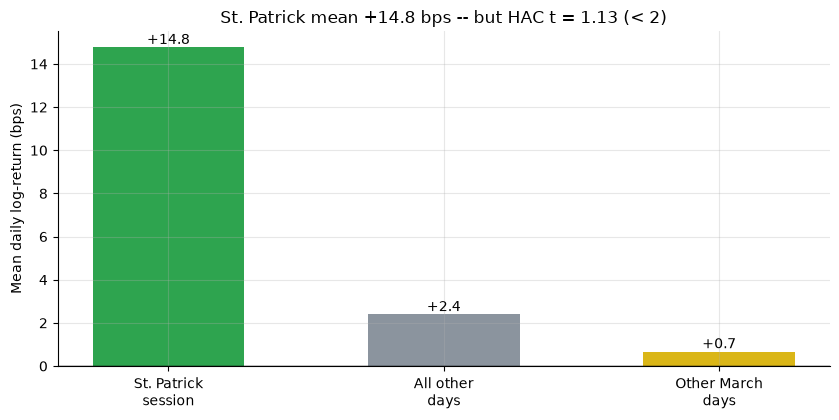

St. Patrick sessions: 99 (1928-2026)
Mean: +14.8 bps  |  all other days: +2.4 bps  |  HAC t = 1.13
A +14.8 bps day sounds great until you see the t-stat: noise.


In [2]:
if HAVE_REAL:
    df = data.fetch_gspc(fetch=False)
    pri = st.stpat_comparison(df)
    n_ev = pri['n_stpat']
    m_sp = pri['mean_stpat_bps']
    m_all = pri['mean_all_bps']
    m_mar = pri['mean_march_other_bps']
    t_hac = pri['tstat_stpat_hac']
else:
    n_ev = R['n_stpat']
    m_sp = R['mean_stpat_bps']; m_all = R['mean_all_bps']
    m_mar = R['mean_march_other_bps']; t_hac = R['tstat_stpat_hac']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['St. Patrick\nsession', 'All other\ndays', 'Other March\ndays'],
              [m_sp, m_all, m_mar], color=[GREEN, GREY, AMBER], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily log-return (bps)')
ax.set_title(f'St. Patrick mean +{m_sp:.1f} bps -- but HAC t = {t_hac:.2f} (< 2)')
for b, v in zip(bars, [m_sp, m_all, m_mar]):
    ax.annotate(f'{v:+.1f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'St. Patrick sessions: {n_ev} (1928-2026)')
print(f'Mean: {m_sp:+.1f} bps  |  all other days: {m_all:+.1f} bps  |  HAC t = {t_hac:.2f}')
print('A +14.8 bps day sounds great until you see the t-stat: noise.')

The St. Patrick's session does average **+14.8 bps** -- about six times the +2.4 bps unconditional drift. But the HAC t-stat is only **1.13**: with 99 noisy daily observations (~131 bps daily standard deviation), a +14.8 bps mean is comfortably inside what chance produces. It does not clear the t=2 bar.

**Is the bump real, or does it live in one lucky era?**

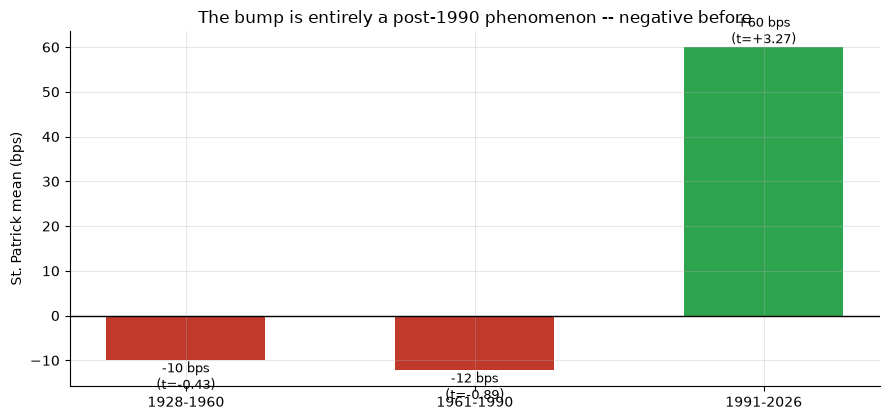

1928-1960: -9.9 bps | 1961-1990: -12.2 bps | 1991-2026: +59.9 bps
A real signal does not flip sign across regimes. This one does.


In [3]:
if HAVE_REAL:
    sub = st.subperiod_table(df)
    labels = sub['period'].tolist()
    vals = sub['mean_bps'].tolist()
    tsts = sub['tstat_hac'].tolist()
else:
    labels = [R['sub_a_lbl'], R['sub_b_lbl'], R['sub_c_lbl']]
    vals = [R['sub_a_bps'], R['sub_b_bps'], R['sub_c_bps']]
    tsts = [R['sub_a_t'], R['sub_b_t'], R['sub_c_t']]

fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if v > 0 else RED for v in vals]
bars = ax.bar(labels, vals, color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('St. Patrick mean (bps)')
ax.set_title('The bump is entirely a post-1990 phenomenon -- negative before')
for b, v, t in zip(bars, vals, tsts):
    ax.annotate(f'{v:+.0f} bps\n(t={t:+.2f})',
                (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print('1928-1960:', f'{vals[0]:+.1f} bps', '| 1961-1990:', f'{vals[1]:+.1f} bps',
      '| 1991-2026:', f'{vals[2]:+.1f} bps')
print('A real signal does not flip sign across regimes. This one does.')

Here is the kill shot. The St. Patrick's bump is **+59.9 bps** in 1991-2026 (t = 3.27) but **negative** in both 1928-1960 (-9.9 bps) and 1961-1990 (-12.2 bps). The famous 'green rally' is really just the last 35 years getting lucky on one calendar slot. A signal that exists only in one regime and reverses in the others is a regime artifact, not an exploitable edge.

## 5 - The verdict

- **Signal -- None.** Full-sample mean +14.8 bps but HAC t = **1.13**; vs other March days Welch p = **0.30**. The whole effect lives in one post-1990 sub-period and is negative before it -- the hallmark of a regime artifact, not a stable signal.
- **Tradability -- Mirage.** One day a year, ~13 bps net of costs. There is no vehicle that beats simply holding the index, which captures the same upward drift every day.
- **Busted.** A placebo a week later (March 24) is a flat +3.5 bps, and no March anchor day survives a Bonferroni correction. March 17 is just one lucky number.

## 6 - Could you actually trade it?

The 'strategy' is to sit in cash all year and be long the index only on the St. Patrick's session. One round-trip a year, so costs are tiny -- but so is the prize.

In [4]:
if HAVE_REAL:
    pnl = st.strategy_pnl(df, one_way_bps=1.0)
    net_bps = pnl['net_mean_bps']
    net_t = pnl['net_tstat_hac']
    bah = pnl['bah_daily_ann_pct']
else:
    net_bps = R['net_mean_bps']; net_t = R['net_tstat_hac']; bah = None

print(f'St. Patrick trade (net of 2 bps round-trip): {net_bps:+.1f} bps/event, HAC t = {net_t:.2f}')
if bah is not None:
    print(f'Buy-and-hold the index: {bah:+.1f}%/yr -- earned every single day, not one.')
print()
print('Being in the market ONE day a year forfeits ~250 other drift days.')
print('The only real trade here is: do not build a portfolio around a holiday.')

St. Patrick trade (net of 2 bps round-trip): +12.8 bps/event, HAC t = 0.98
Buy-and-hold the index: +6.3%/yr -- earned every single day, not one.

Being in the market ONE day a year forfeits ~250 other drift days.
The only real trade here is: do not build a portfolio around a holiday.


Net of a 2 bps round-trip the bump is ~13 bps for one day -- and not statistically distinguishable from zero. Buy-and-hold earns the market's drift every day of the year; the St. Patrick trade earns it once. There is no edge to harvest.

## 7 - Going further

- **The positive control:** the companion notebook plants a synthetic St. Patrick bump and shows the same engine lights up (HAC t >> 2) when an effect truly exists. The real tape has nothing like that.
- **Same family:** other fixed-date calendar folklore -- the [Super-Bowl indicator](../../158-super-bowl/), [Friday-the-13th](../../163-friday-13th/), and the [year-ending-in-five](../../161-year-ending-five/) lore -- all share the small-n, multiple-comparisons trap.

*Think March 17 really is special? Fork this, pre-register the date, and show a stable HAC t >= 2 that survives the placebo and the sub-period split. That's the bar -- and it isn't cleared.*